In [212]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.tree import plot_tree


In [213]:
df_test = pd.read_csv('C:\\Users\\Student\\INTRO_ML\\challenge1_test.csv')
df_train = pd.read_csv('C:\\Users\\Student\\INTRO_ML\\challenge1_train.csv')


In [214]:
df_train.head()

,ID,price,bathrooms,bedrooms,square_feet,latitude,longitude,category,has_photo,state
0,2,925,1.0,0,116,47.6160,-122.3275,housing/rent/apartment,Thumbnail,WA
1,3,2475,1.0,0,130,40.7629,-73.9885,housing/rent/apartment,Thumbnail,NY
2,5,1695,1.0,0,190,37.7599,-122.4379,housing/rent/apartment,Thumbnail,CA
3,6,1560,1.0,1,200,35.0847,-77.0609,housing/rent/apartment,Thumbnail,NC
4,7,1560,1.0,1,200,35.0960,-77.0272,housing/rent/apartment,Thumbnail,NC


In [215]:
df_test.head()

,ID,bathrooms,bedrooms,square_feet,latitude,longitude,category,has_photo,state
0,1,1.0,0,107,38.8910,-77.0816,housing/rent/apartment,Thumbnail,VA
1,4,1.0,0,138,37.7599,-122.4379,housing/rent/apartment,Thumbnail,CA
2,9,1.0,1,200,38.1172,-122.2313,housing/rent/apartment,Thumbnail,CA
3,11,1.0,1,200,35.2016,-80.8124,housing/rent/apartment,Thumbnail,NC
4,13,1.0,1,200,33.5178,-112.0848,housing/rent/apartment,Thumbnail,AZ


In [216]:
df_train.tail()

,ID,price,bathrooms,bedrooms,square_feet,latitude,longitude,category,has_photo,state
7393,9858,8345,4.0,8,4900,43.0724,-89.4003,housing/rent/apartment,Thumbnail,WI
7394,9860,3200,5.0,6,5199,33.4072,-84.4523,housing/rent/apartment,Thumbnail,GA
7395,9861,4500,5.0,4,5407,44.8653,-93.4749,housing/rent/apartment,Thumbnail,MN
7396,9862,6900,5.0,5,5700,28.1253,-82.4468,housing/rent/apartment,Thumbnail,FL
7397,9863,3000,4.0,6,5921,37.0835,-113.5823,housing/rent/apartment,Thumbnail,UT


In [217]:
df_test.tail()

,ID,bathrooms,bedrooms,square_feet,latitude,longitude,category,has_photo,state
2462,9855,4.5,6,4733,32.7876,-117.1265,housing/rent/apartment,Thumbnail,CA
2463,9856,4.0,5,4736,39.9974,-82.9829,housing/rent/apartment,Thumbnail,OH
2464,9859,3.5,5,4970,39.8228,-105.1107,housing/rent/apartment,Thumbnail,CO
2465,9864,4.0,5,6300,44.9000,-93.3233,housing/rent/apartment,Thumbnail,MN
2466,9865,1.0,1,880,34.0072,-84.0034,housing/rent/apartment,No,GA


In [218]:
print("The shape of the training dataset is: ", df_train.shape, "\nthe shape of the testing dataset is: ", df_test.shape)

The shape of the training dataset is:  (7398, 10) 
the shape of the testing dataset is:  (2467, 9)


In [219]:
df_test.columns.tolist()

['ID',
 'bathrooms',
 'bedrooms',
 'square_feet',
 'latitude',
 'longitude',
 'category',
 'has_photo',
 'state']

In [220]:
df_train.columns.tolist()

['ID',
 'price',
 'bathrooms',
 'bedrooms',
 'square_feet',
 'latitude',
 'longitude',
 'category',
 'has_photo',
 'state']

In [221]:
df_test.describe().round(2)

,ID,bathrooms,bedrooms,square_feet,latitude,longitude
count,2467.00,2467.00,2467.00,2467.00,2467.00,2467.00
mean,4869.79,1.37,1.74,931.68,37.82,-95.22
std,2855.38,0.59,0.93,507.04,5.50,15.97
min,1.00,1.00,0.00,107.00,21.32,-157.84
25%,2377.00,1.00,1.00,642.00,33.74,-104.91
50%,4814.00,1.00,2.00,800.00,38.78,-93.67
75%,7301.50,2.00,2.00,1088.50,41.58,-82.86
max,9865.00,5.00,6.00,6300.00,61.59,-70.19


In [222]:
df_train.describe().round(2)

,ID,price,bathrooms,bedrooms,square_feet,latitude,longitude
count,7398.00,7398.00,7398.00,7398.00,7398.00,7398.00,7398.00
mean,4954.08,1462.81,1.38,1.74,940.94,37.65,-94.41
std,2845.31,821.58,0.60,0.94,502.25,5.52,15.72
min,2.00,200.00,1.00,0.00,116.00,21.32,-158.02
25%,2495.25,949.00,1.00,1.00,650.00,33.60,-98.53
50%,4972.50,1273.50,1.00,2.00,807.50,38.77,-93.65
75%,7435.75,1695.00,2.00,2.00,1100.00,41.35,-81.64
max,9863.00,8800.00,7.00,9.00,5921.00,61.59,-70.35


In [223]:
df_test.columns.tolist()

['ID',
 'bathrooms',
 'bedrooms',
 'square_feet',
 'latitude',
 'longitude',
 'category',
 'has_photo',
 'state']

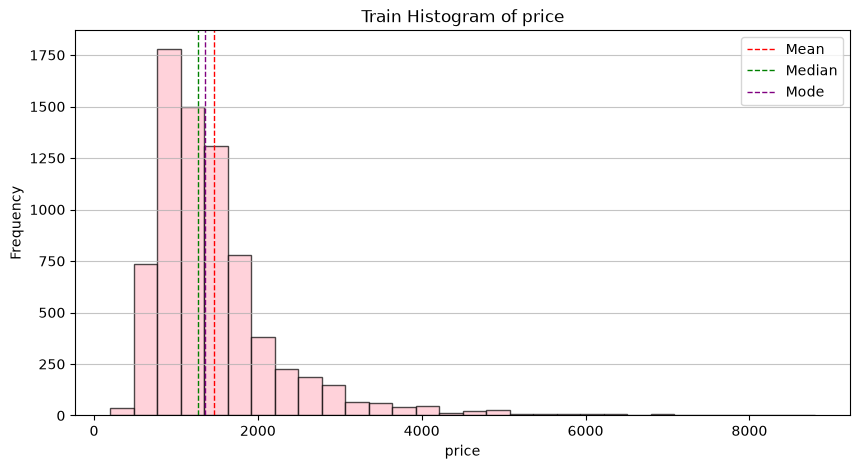

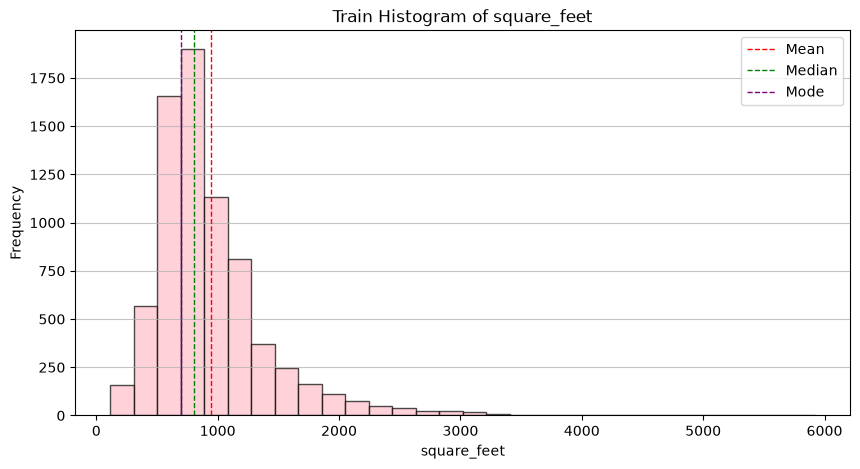

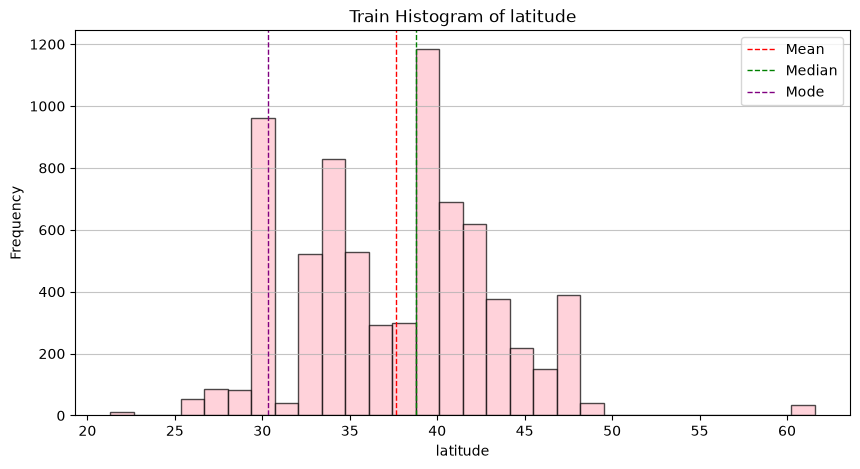

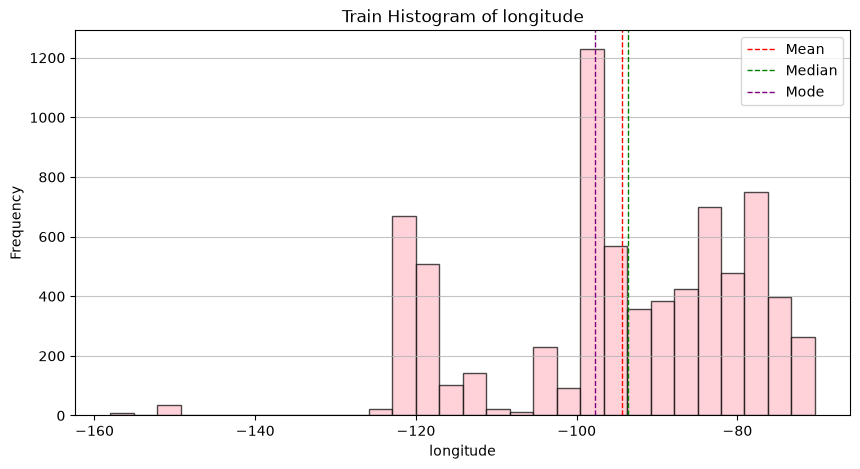

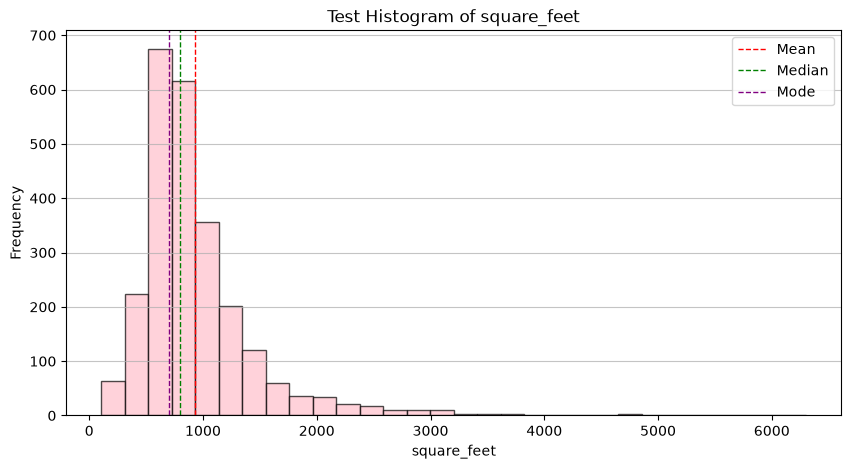

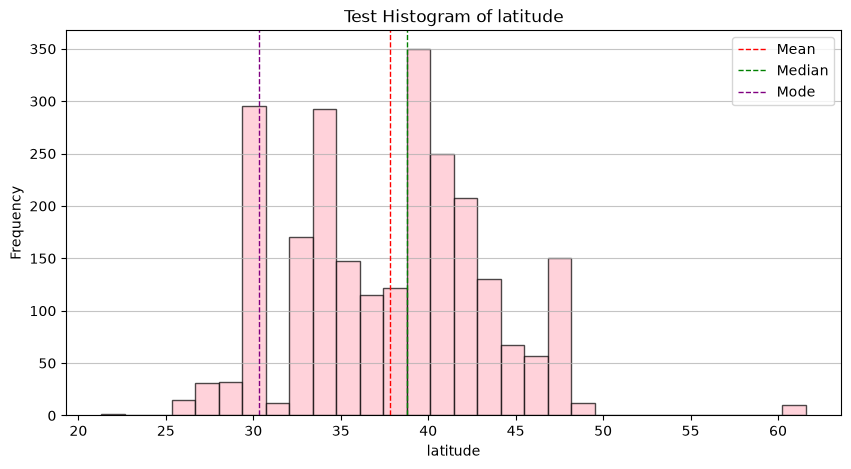

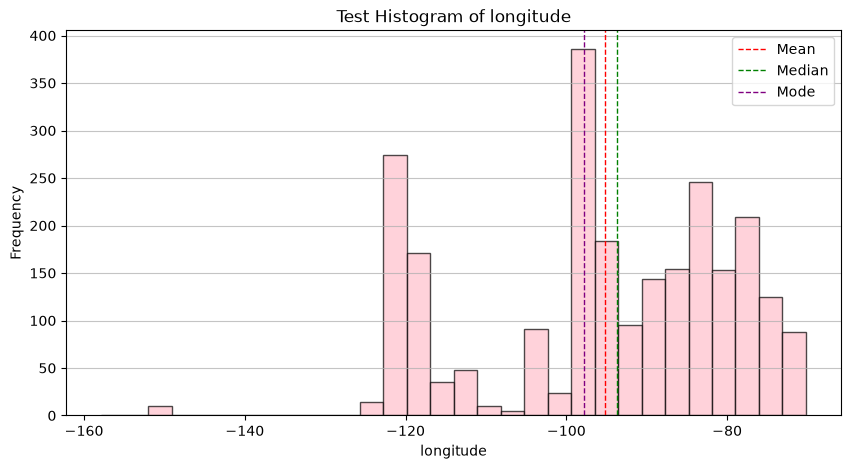

In [224]:
excluded_cols = ('ID', 'bathrooms', 'bedrooms', 'category', 'has_photo', 'state')

def plot_hist(df, name):
    for col in df.columns:
        if col in excluded_cols:
            continue
        plt.figure(figsize=(10, 5))
        plt.hist(df[col], bins=30, alpha=0.7, color='pink', edgecolor='black')
        plt.title(f'{name} Histogram of {col}')
        plt.xlabel(col)
        plt.ylabel('Frequency')
        plt.axvline(df[col].mean(), color='red', linestyle='dashed', linewidth=1, label='Mean')
        plt.axvline(df[col].median(), color='green', linestyle='dashed', linewidth=1, label='Median')
        plt.axvline(df[col].mode()[0], color='purple', linestyle='dashed', linewidth=1, label='Mode')
        plt.legend()
        plt.grid(axis='y', alpha=0.75)
        plt.show()

plot_hist(df_train, "Train")
plot_hist(df_test, "Test")

<Axes: xlabel='state'>

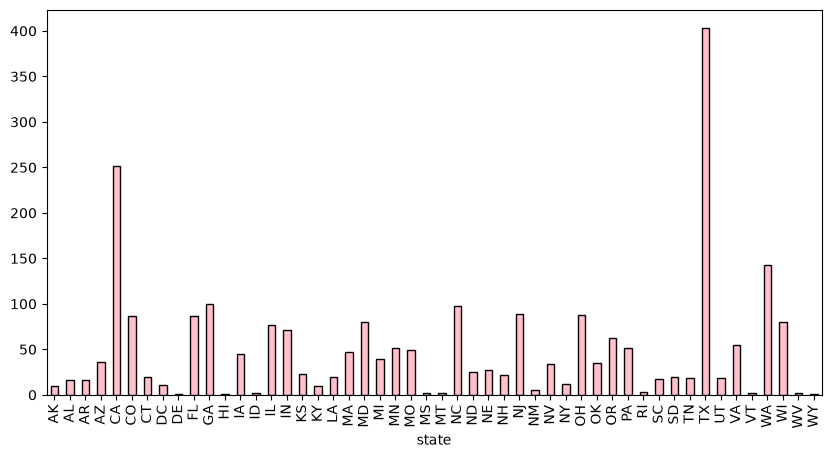

In [225]:
df_test.groupby('state').size().plot(kind='bar', figsize=(10, 5), color='pink', edgecolor='black')

<Axes: xlabel='state'>

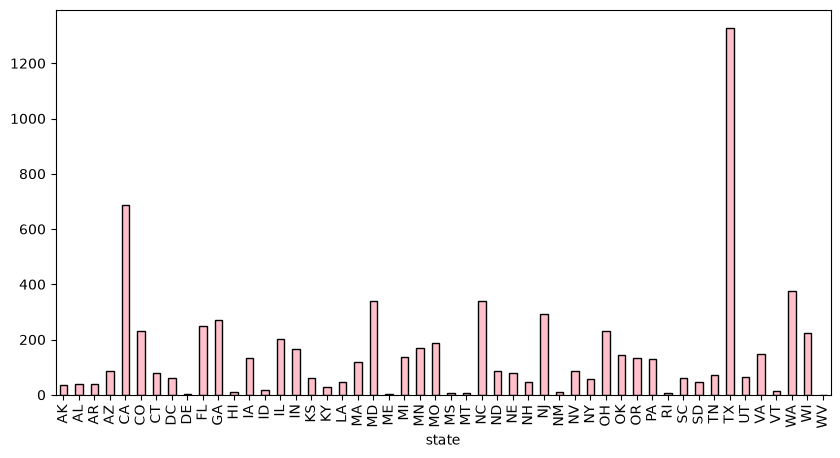

In [226]:
df_train.groupby('state').size().plot(kind='bar', figsize=(10, 5), color='pink', edgecolor='black')

In [227]:
df_train.head(5)

,ID,price,bathrooms,bedrooms,square_feet,latitude,longitude,category,has_photo,state
0,2,925,1.0,0,116,47.6160,-122.3275,housing/rent/apartment,Thumbnail,WA
1,3,2475,1.0,0,130,40.7629,-73.9885,housing/rent/apartment,Thumbnail,NY
2,5,1695,1.0,0,190,37.7599,-122.4379,housing/rent/apartment,Thumbnail,CA
3,6,1560,1.0,1,200,35.0847,-77.0609,housing/rent/apartment,Thumbnail,NC
4,7,1560,1.0,1,200,35.0960,-77.0272,housing/rent/apartment,Thumbnail,NC


### Data Analysis 
* price is the target for the prediction 

In [228]:
# columntransformer: -> num_pipeline -> genre -> simpleimputer->standard scaler/onehot encoder -> decion tree classifier

In [229]:
# combined view for category counts only; never used for training
df = pd.concat([df_train.drop(columns="price"), df_test], axis=0).set_index("ID")

In [230]:
df_null =  df[df.isnull().sum()[df.isnull().sum()>0].index]

In [231]:
df.info()

<class 'pandas.DataFrame'>
Index: 9865 entries, 2 to 9865
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   bathrooms    9865 non-null   float64
 1   bedrooms     9865 non-null   int64  
 2   square_feet  9865 non-null   int64  
 3   latitude     9865 non-null   float64
 4   longitude    9865 non-null   float64
 5   category     9865 non-null   str    
 6   has_photo    9865 non-null   str    
 7   state        9865 non-null   str    
dtypes: float64(3), int64(2), str(3)
memory usage: 693.6 KB


In [232]:
df['category'].value_counts() 

category
housing/rent/apartment     9862
housing/rent/home             2
housing/rent/short_term       1
Name: count, dtype: int64

In [233]:
df['has_photo'].value_counts() # one hot encoding since it has three categories  and no need for precedence 

has_photo
Thumbnail    8774
Yes           908
No            183
Name: count, dtype: int64

In [234]:
categorical_columns = df.select_dtypes(include=['object']).columns


C:\Users\Student\AppData\Local\Temp\ipykernel_23744\331369101.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = df.select_dtypes(include=['object']).columns


In [235]:
df['state'].value_counts() # one hot encoding since it has many categories and no need for precedence 

state
TX    1730
CA     940
WA     518
NC     438
MD     421
NJ     383
GA     371
FL     336
OH     320
CO     317
WI     302
IL     280
MO     238
IN     236
MN     221
VA     204
OR     197
PA     182
IA     179
OK     178
MI     176
MA     166
AZ     123
NV     120
ND     112
NE     105
CT      98
TN      91
UT      84
KS      83
SC      77
DC      73
NH      70
NY      68
LA      66
SD      66
AL      56
AR      56
AK      44
KY      40
ID      21
VT      16
NM      14
RI      11
HI      11
MS       9
MT       7
DE       5
WV       3
ME       2
WY       1
Name: count, dtype: int64

In [236]:
column_to_encode = ["has_photo", "state"]

encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
train_encoded = encoder.fit_transform(df_train[column_to_encode])   # fit on train only
test_encoded = encoder.transform(df_test[column_to_encode])         # transform test only

encoded_names = encoder.get_feature_names_out(column_to_encode)

train_encoded_df = pd.DataFrame(train_encoded, columns=encoded_names, index=df_train.index)
test_encoded_df = pd.DataFrame(test_encoded, columns=encoded_names, index=df_test.index)

train_final = pd.concat([df_train.drop(columns=column_to_encode), train_encoded_df], axis=1)
test_final = pd.concat([df_test.drop(columns=column_to_encode), test_encoded_df], axis=1)

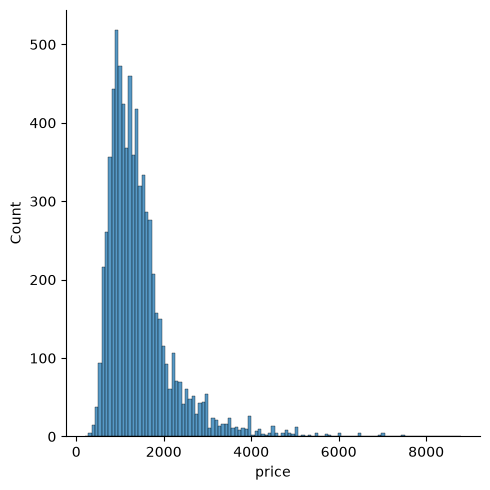

In [237]:
sns.displot(df_train['price'])

<Axes: xlabel='square_feet', ylabel='price'>

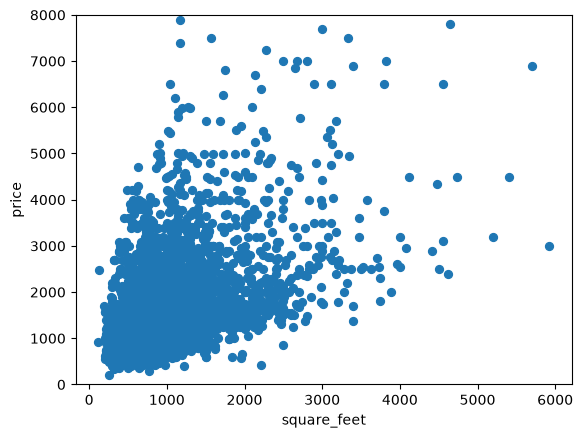

In [238]:
data = pd.concat([df_train['price'], df_train['square_feet']], axis=1)
data.plot.scatter(x='square_feet', y='price', ylim=(0,8000), s=32)

<Axes: >

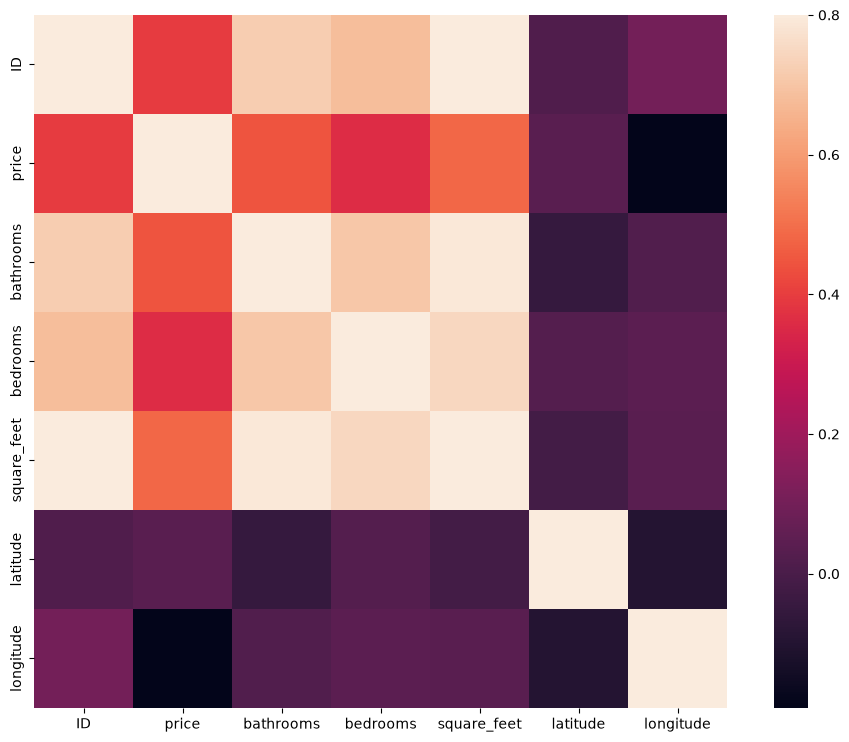

In [239]:
corr_mat = df_train.select_dtypes(include=['number']).corr()
f, ax = plt.subplots(figsize=(12,9))
sns.heatmap(corr_mat, vmax=0.8, square=True)

### Models 
1) Simple/Multiple Linear Regression 
2) Decision Tree 
3) Random Forest 
4) Gradient Boost 
5) Ridge and Lasso Regression

In [240]:
X = train_final.drop(columns=["price", "category"])
y = train_final["price"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

#### 1. Simple/Multiple Linear Regression Summary
* might have a promblem with heteroscedasticity price vs sqr ftg: check Residual = actual price − predicted price
* rmse


In [241]:
from sklearn.linear_model import LinearRegression


Train RMSE: 710.9846505017956
Test RMSE:  749.0847527514582


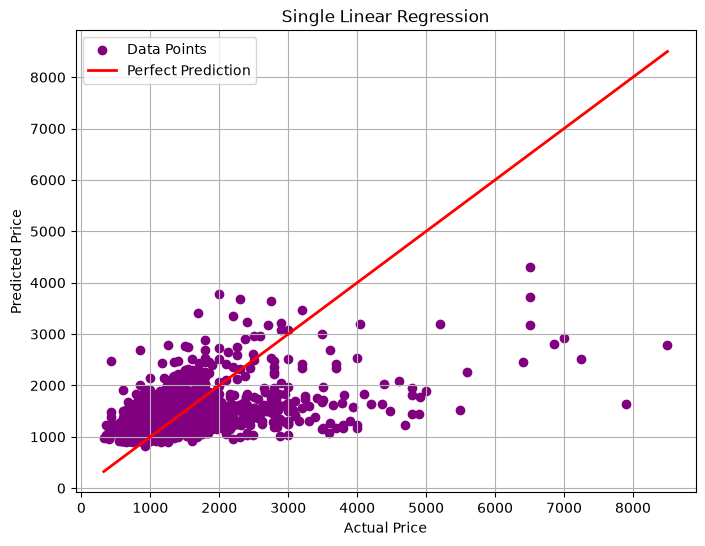

In [242]:
from sklearn.metrics import root_mean_squared_error

# single linear regression
X_SLR = train_final[["square_feet"]]
y_SLR = train_final["price"]

X_train_SLR, X_test_SLR, y_train_SLR, y_test_SLR = train_test_split(
    X_SLR, y_SLR, test_size=0.2, random_state=42
)
LR_Regressor = LinearRegression()
LR_Regressor.fit(X_train_SLR, y_train_SLR)
y_pred_SLR = LR_Regressor.predict(X_test_SLR)

print("Train RMSE:", root_mean_squared_error(y_train_SLR, LR_Regressor.predict(X_train_SLR)))
print("Test RMSE: ", root_mean_squared_error(y_test_SLR, y_pred_SLR))

plt.figure(figsize=(8,6))
plt.scatter(y_test_SLR, y_pred_SLR, color='purple', label='Data Points')
plt.plot([y_test_SLR.min(), y_test_SLR.max()], [y_test_SLR.min(), y_test_SLR.max()],
         color='red', linewidth=2, label='Perfect Prediction')
plt.title("Single Linear Regression")
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.legend()
plt.grid(True)
plt.show()

Train RMSE: 515.1375701849718
Test RMSE:  550.037759544286


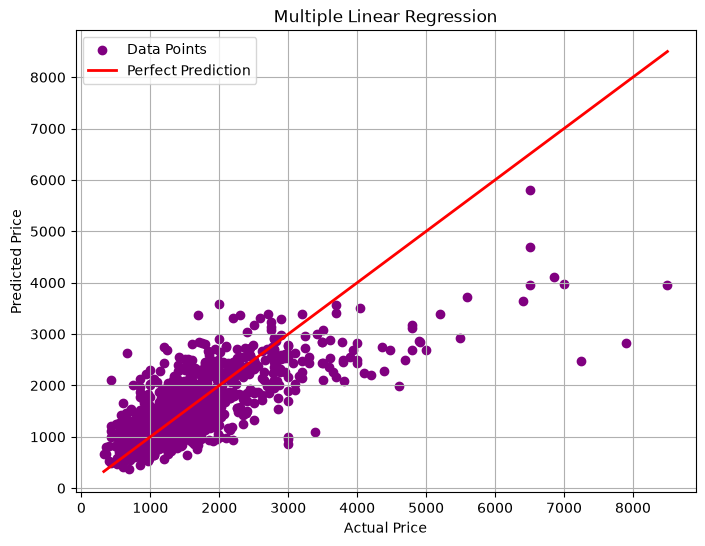

In [243]:
# Multiple Linear Regression
X2 = train_final.drop(columns=["ID", "price", "category"])   # ID must never be a feature
y2 = train_final["price"]

X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X2, y2, test_size=0.2, random_state=42
)
model = LinearRegression()
model.fit(X_train2, y_train2)
y_pred2 = model.predict(X_test2)

print("Train RMSE:", root_mean_squared_error(y_train2, model.predict(X_train2)))
print("Test RMSE: ", root_mean_squared_error(y_test2, y_pred2))

plt.figure(figsize=(8,6))
plt.scatter(y_test2, y_pred2, color='purple', label='Data Points')
plt.plot([y_test2.min(), y_test2.max()], [y_test2.min(), y_test2.max()],
         color='red', linewidth=2, label='Perfect Prediction')
plt.title('Multiple Linear Regression')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.legend()
plt.grid(True)
plt.show()

ValueError: The feature names should match those that were passed during fit.
Feature names unseen at fit time:
- ID
- bathrooms
- bedrooms
- has_photo_No
- has_photo_Thumbnail
- ...


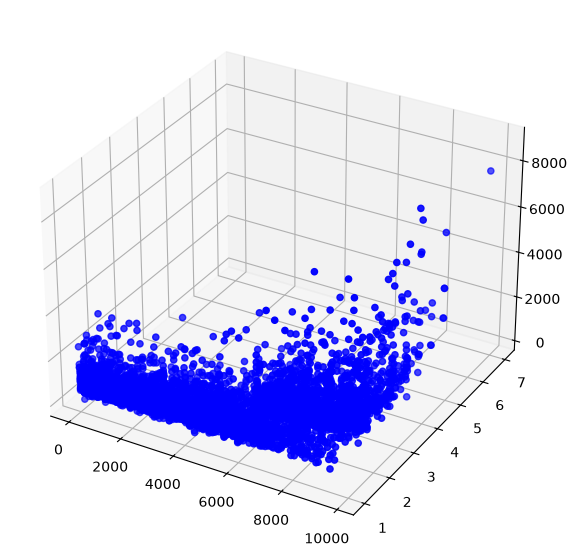

In [244]:
fig = plt.figure(figsize=(10,7))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(
    X_train_MLR.iloc[:,0],
    X_train_MLR.iloc[:,1],
    y_train_MLR,
    color='blue',
    label='Data'
)

X_MLR_SURF_1, X_MLR_SURF_2 = np.meshgrid(
    np.linspace(X_train_MLR.iloc[:,0].min(), X_train_MLR.iloc[:,0].max(), 10),
    np.linspace(X_train_MLR.iloc[:,1].min(), X_train_MLR.iloc[:,1].max(), 10)
)

# Start with the mean of all 59 features
X_MLR_SURF = pd.DataFrame(
    np.tile(X_train_MLR.mean().values, (X_MLR_SURF_1.size, 1)),
    columns=X_train_MLR.columns
)

# Replace the first two features with the surface values
X_MLR_SURF.iloc[:,0] = X_MLR_SURF_1.ravel()
X_MLR_SURF.iloc[:,1] = X_MLR_SURF_2.ravel()

# Predict using all 59 features
Y_MLR_SURF = LR_Regressor.predict(X_MLR_SURF).reshape(
    X_MLR_SURF_1.shape
)

ax.plot_surface(
    X_MLR_SURF_1,
    X_MLR_SURF_2,
    Y_MLR_SURF,
    color='red',
    alpha=0.5
)

ax.set_xlabel(X_train_MLR.columns[0])
ax.set_ylabel(X_train_MLR.columns[1])
ax.set_zlabel('Price')
ax.set_title("Multiple Linear Regression with Regression Plane")
ax.legend()

plt.show()

2.  Decision Tree

In [ ]:
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.metrics import mean_squared_error

In [ ]:
regressor_DT = DecisionTreeRegressor(max_depth=4, random_state=43)
regressor_DT.fit(X_train,y_train)
y_pred_DT= regressor_DT.predict(X_test)
mse_DT = mean_squared_error(y_test, y_pred_DT)

In [ ]:
f"{mse_DT:4f}"

'351670.935884'

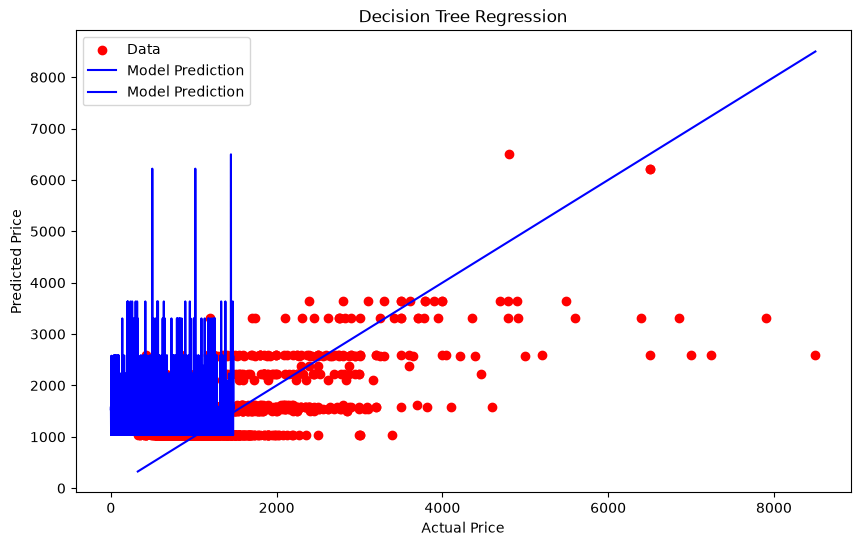

In [ ]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_DT, color='red', label='Data')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], y_pred_DT, color='blue', label='Model Prediction')
plt.title("Decision Tree Regression")
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.legend()
plt.show()

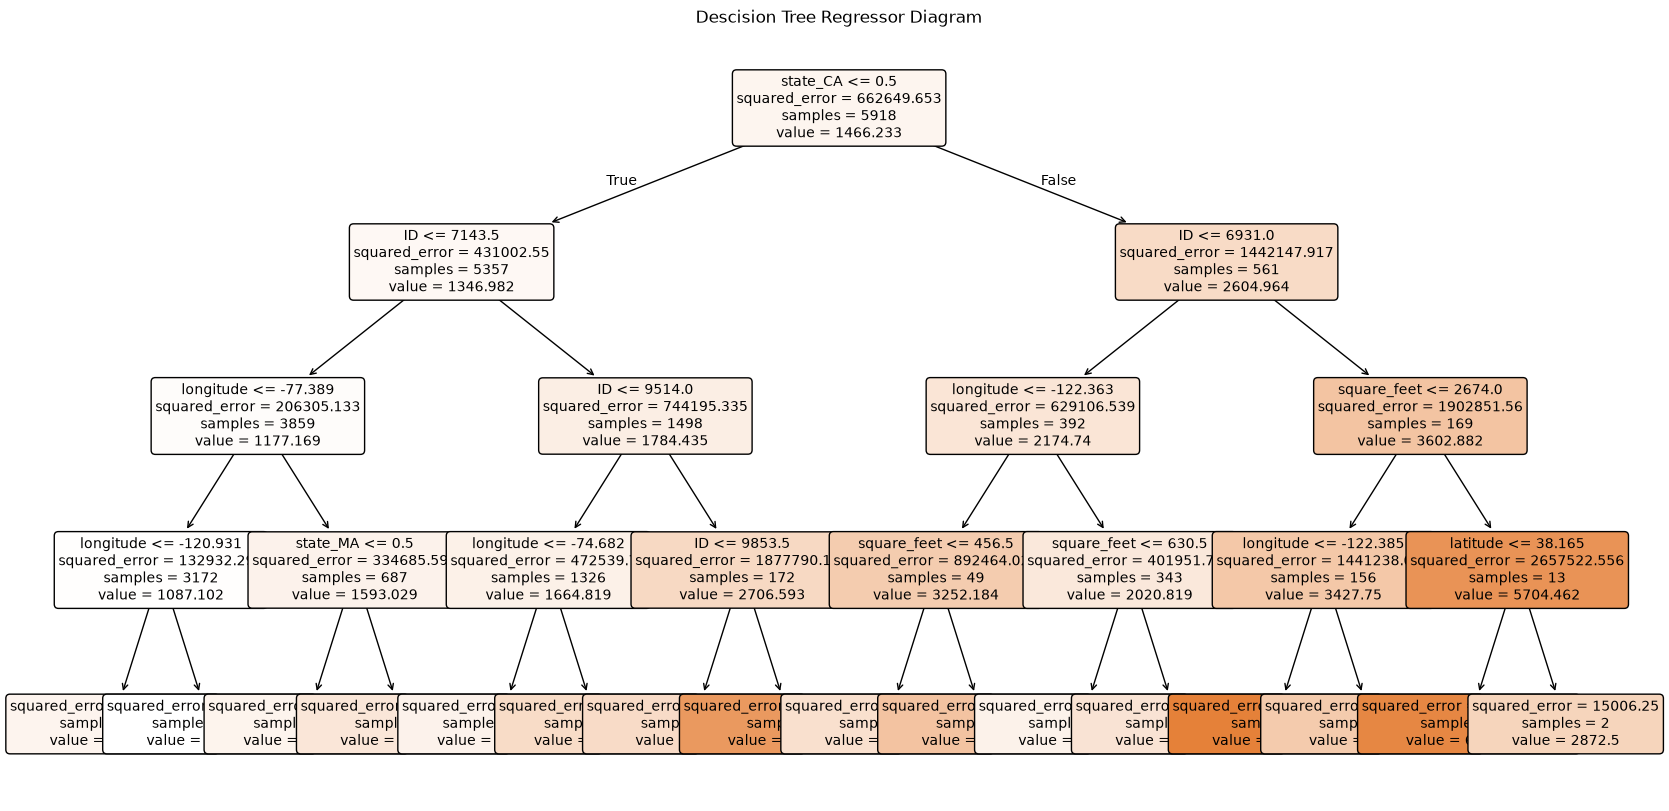

In [ ]:
plt.figure(figsize=(20,10))
plot_tree(
    regressor_DT,
    feature_names=X_train.columns.tolist(),
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title("Descision Tree Regressor Diagram")
plt.show()

3) Random Forest Regression

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [ ]:
RF_Regressor = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    oob_score=True
)

In [ ]:
RF_Regressor.fit(X_train, y_train)
Y_pred_RF = RF_Regressor.predict(X_test)
mse_RF = mean_squared_error(y_test, Y_pred_RF)
r2_score_RF = r2_score(y_test,Y_pred_RF)

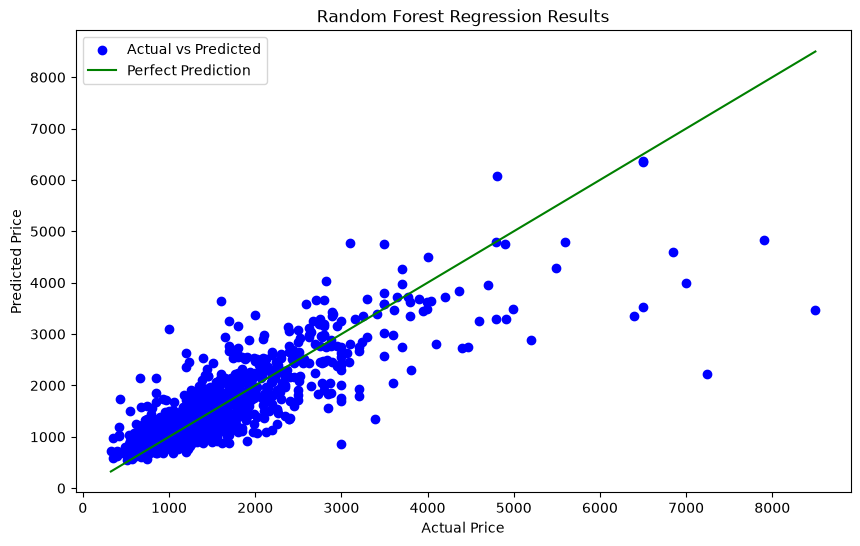

In [ ]:
plt.figure(figsize=(10,6))

plt.scatter(
    y_test,
    Y_pred_RF,
    color='blue',
    label='Actual vs Predicted'
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color='green',
    label='Perfect Prediction'
)

plt.title("Random Forest Regression Results")
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.legend()
plt.show()

4) Gradient Boost Regression

In [ ]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score, mean_squared_error

In [ ]:
# Model 1
tree_DTR_1 = DecisionTreeRegressor(max_leaf_nodes=8, random_state=42)
tree_DTR_1.fit(X_train, y_train)
pred_1 = tree_DTR_1.predict(X_test)

# Model 2
tree_DTR_2 = DecisionTreeRegressor(max_leaf_nodes=16, random_state=42)
tree_DTR_2.fit(X_train, y_train)
pred_2 = tree_DTR_2.predict(X_test)

# Model 3
tree_DTR_3 = DecisionTreeRegressor(max_leaf_nodes=32, random_state=42)
tree_DTR_3.fit(X_train, y_train)
pred_3 = tree_DTR_3.predict(X_test)

# Results
print("Tree 1")
print("R²:", r2_score(y_test, pred_1))
print("MSE:", mean_squared_error(y_test, pred_1))

print("\nTree 2")
print("R²:", r2_score(y_test, pred_2))
print("MSE:", mean_squared_error(y_test, pred_2))

print("\nTree 3")
print("R²:", r2_score(y_test, pred_3))
print("MSE:", mean_squared_error(y_test, pred_3))

Tree 1
R²: 0.4810298307639167
MSE: 375574.4517126625

Tree 2
R²: 0.5264098678259201
MSE: 342733.2913751615

Tree 3
R²: 0.5764893067668954
MSE: 306491.21247104945


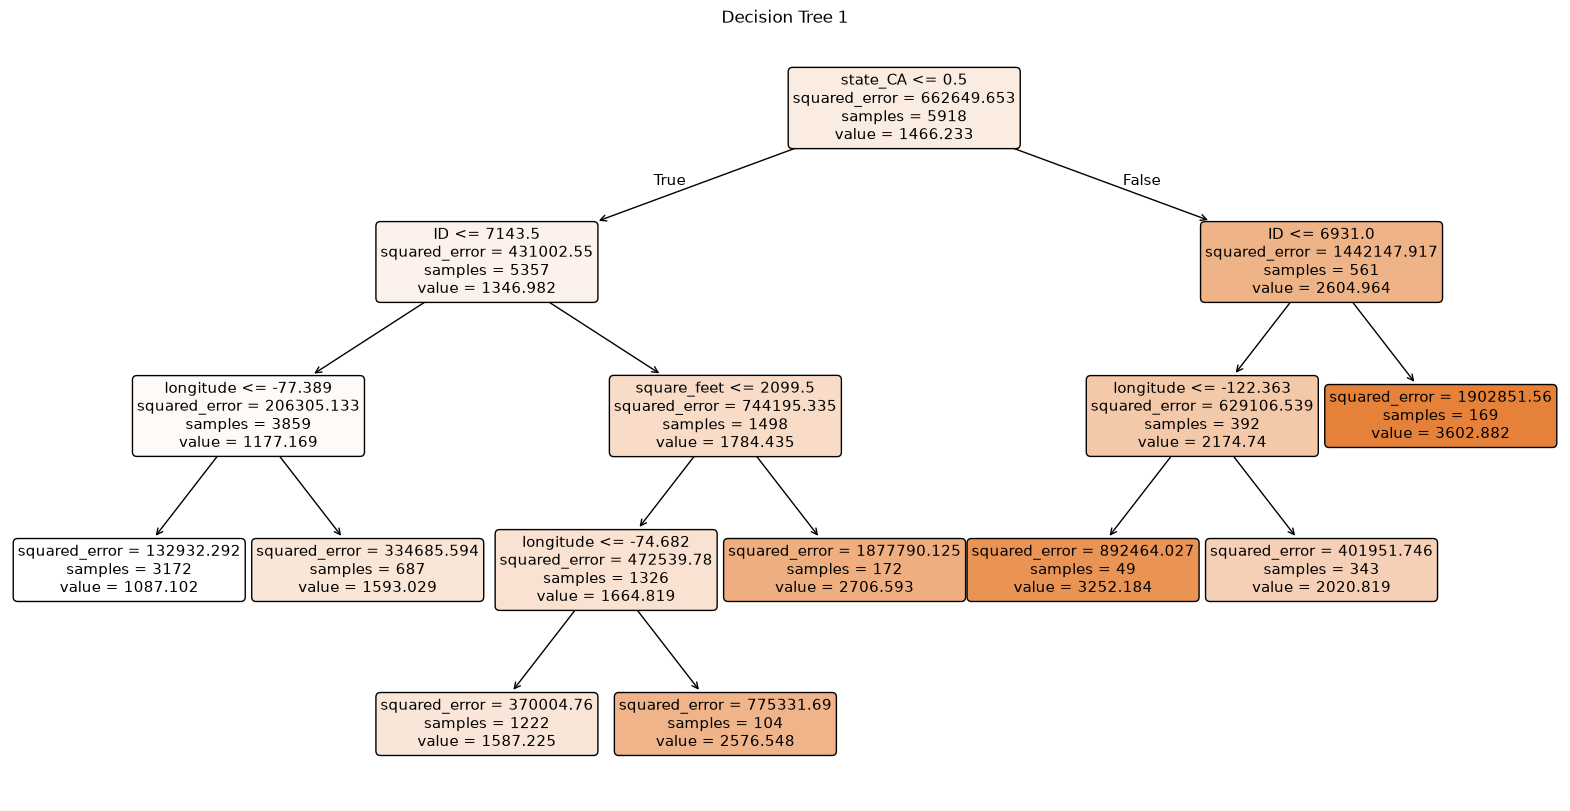

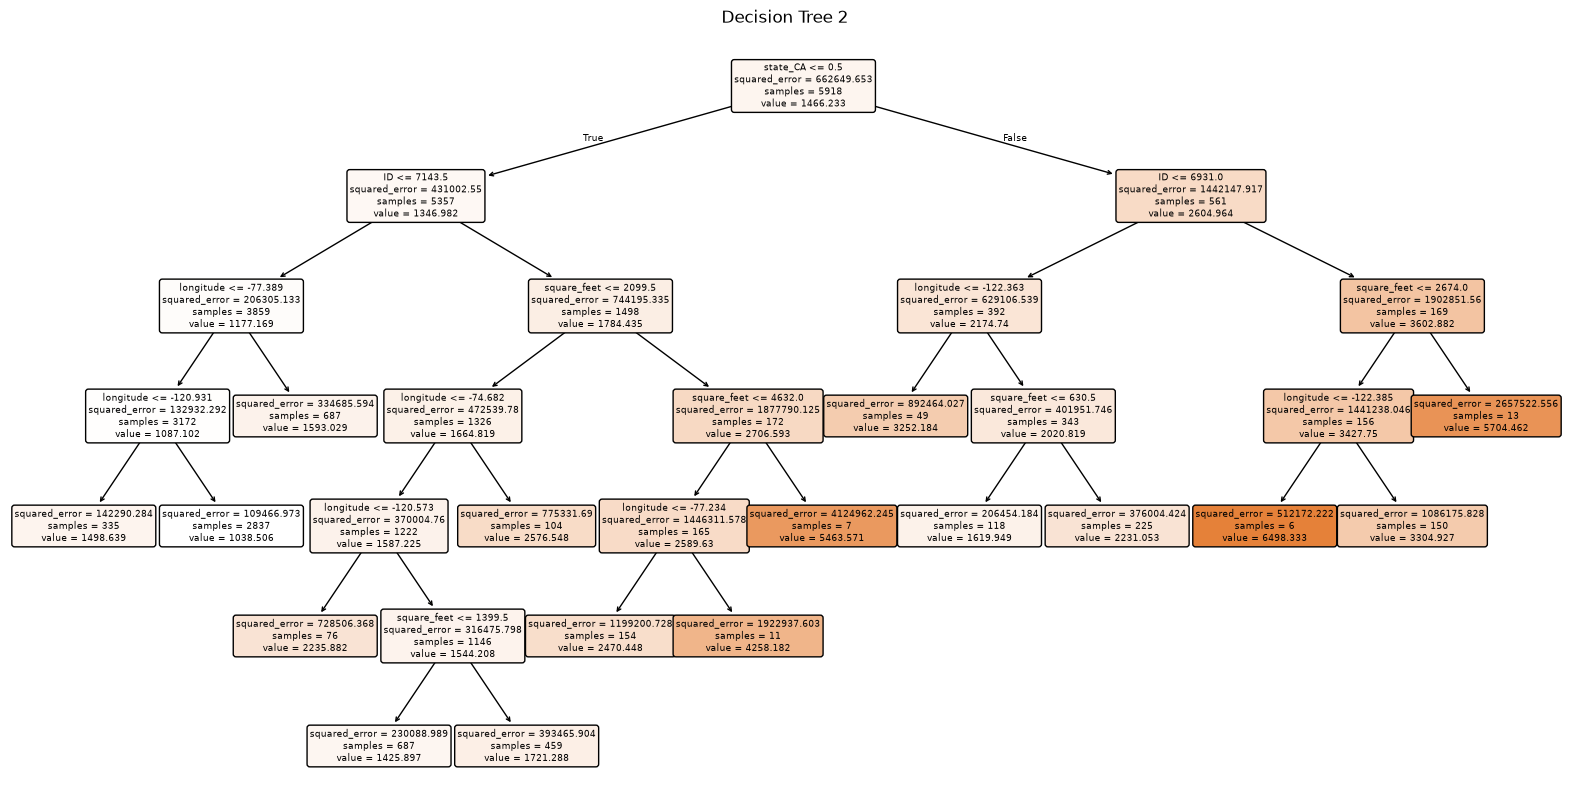

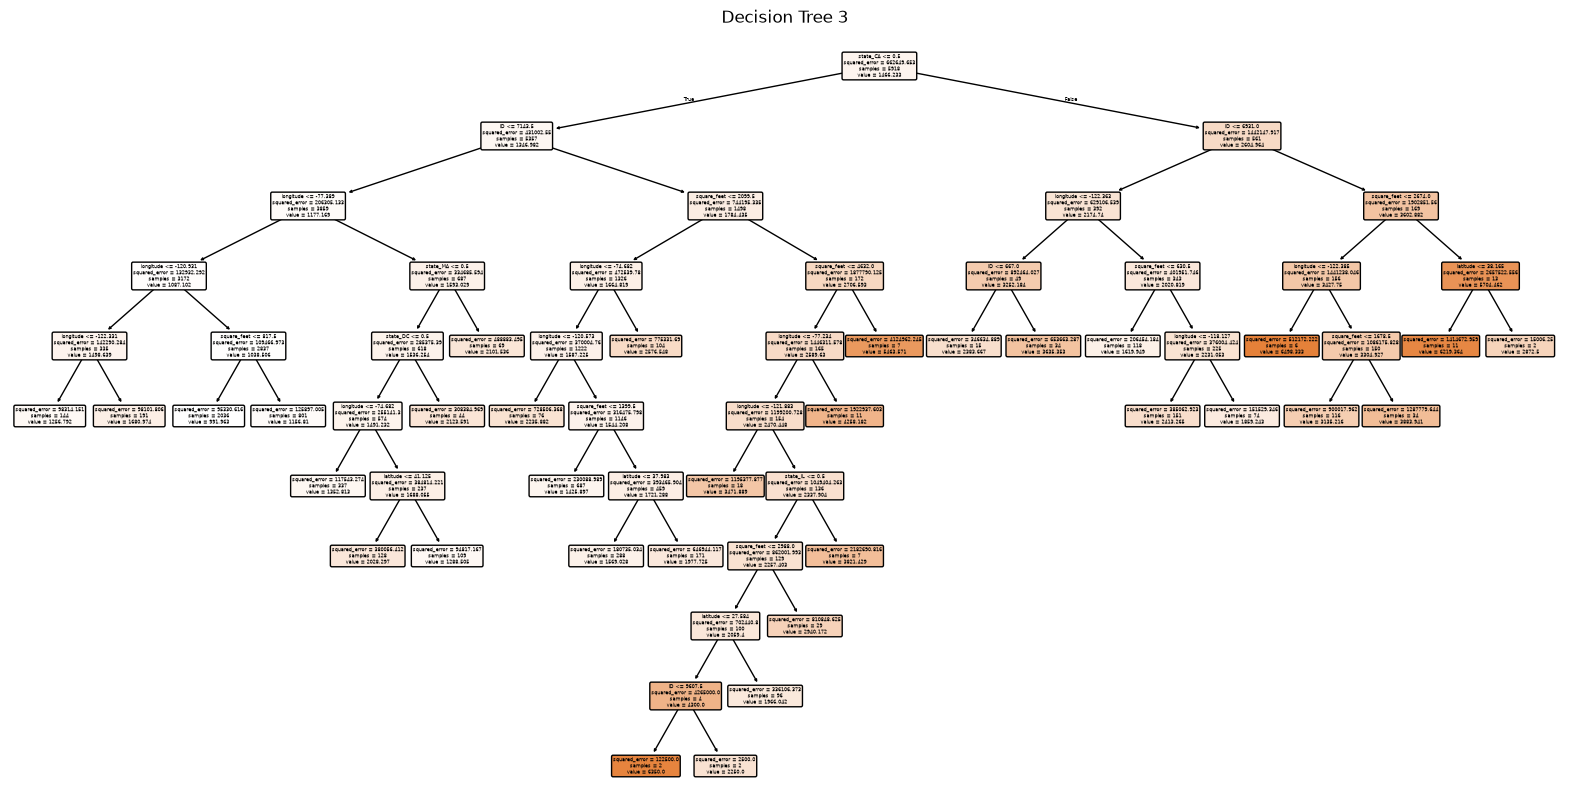

In [ ]:
# Tree 1
plt.figure(figsize=(20, 10))
plot_tree(tree_DTR_1, feature_names=X.columns, filled=True, rounded=True)
plt.title("Decision Tree 1")
plt.show()

# Tree 2
plt.figure(figsize=(20, 10))
plot_tree(tree_DTR_2, feature_names=X.columns, filled=True, rounded=True)
plt.title("Decision Tree 2")
plt.show()

# Tree 3
plt.figure(figsize=(20, 10))
plot_tree(tree_DTR_3, feature_names=X.columns, filled=True, rounded=True)
plt.title("Decision Tree 3")
plt.show()

5) Ridge Regression

In [ ]:
from sklearn.linear_model import RidgeCV
from sklearn.metrics import r2_score
from sklearn.preprocessing import StandardScaler

In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
ridge_cv = RidgeCV(alphas=[0.1, 1.0, 10.0], cv=10)
ridge_cv.fit(X_train_scaled, y_train)
y_pred_ridge = ridge_cv.predict(X_test_scaled)

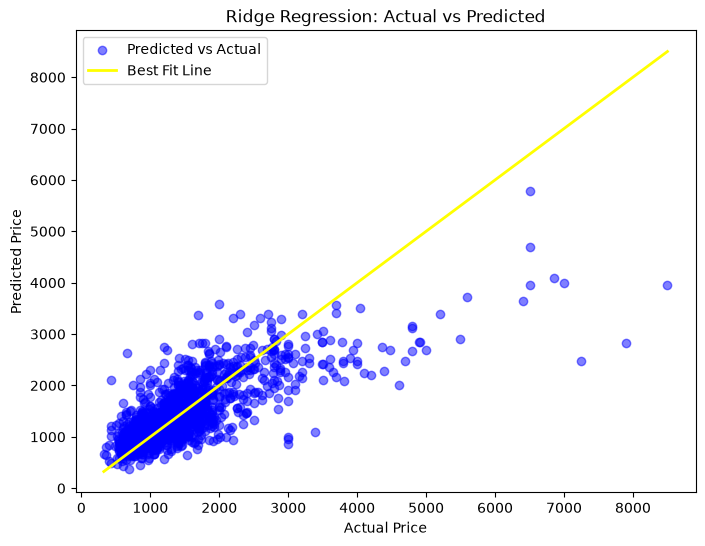

In [ ]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred_ridge, color='blue', alpha=0.5, label='Predicted vs Actual')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='yellow', linewidth=2, label='Best Fit Line')
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Ridge Regression: Actual vs Predicted")
plt.legend()
plt.show()

5) Lasso Regression

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LassoCV
from sklearn.model_selection import RepeatedKFold

In [ ]:
model_LSR = LassoCV(alphas=np.arange(0.01, 1.0, 0.01), cv=10, n_jobs=-1)
model_LSR.fit(X,y)
print(model_LSR.alpha_)

c:\Users\Student\anaconda3\envs\intro_ML\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:827: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 8.793686e+05, tolerance: 4.693e+05
  model = cd_fast.enet_coordinate_descent_gram(
c:\Users\Student\anaconda3\envs\intro_ML\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:827: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 8.136332e+05, tolerance: 4.693e+05
  model = cd_fast.enet_coordinate_descent_gram(
c:\Users\Student\anaconda3\envs\intro_ML\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:827: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or cons

0.01


c:\Users\Student\anaconda3\envs\intro_ML\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:842: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 7.385753e+08, tolerance: 4.993e+05
  model = cd_fast.enet_coordinate_descent(


In [ ]:
# Values correspond to: ID, bathrooms, bedrooms, square_feet
new_values = [24, 2.5, 3.5, 18.5]

new_observation = pd.DataFrame(
    [X.mean().values],
    columns=X.columns
)

new_observation.loc[0, ["ID", "bathrooms", "bedrooms", "square_feet"]] = new_values

model_LSR.predict(new_observation)

# Prediction output is displayed by the previous line.

array([1093.72993376])

In [ ]:
# cross validation
from sklearn.model_selection import cross_val_score

In [ ]:
# cross validation (RMSE, shuffled folds)
from sklearn.model_selection import KFold, cross_validate

cv = KFold(n_splits=5, shuffle=True, random_state=42)
lr = LinearRegression()

res1 = cross_validate(lr, X_SLR, y_SLR, cv=cv,
                      scoring="neg_root_mean_squared_error", return_train_score=True)
res2 = cross_validate(lr, X2, y2, cv=cv,
                      scoring="neg_root_mean_squared_error", return_train_score=True)

In [ ]:
cv_score3 = cross_val_score(regressor_DT, X, y.values.ravel(), cv=10)
cv_tree_1 = cross_val_score(
    tree_DTR_1, X, y, cv=10, scoring='r2'
)

cv_tree_2 = cross_val_score(
    tree_DTR_2, X, y, cv=10, scoring='r2'
)

cv_tree_3 = cross_val_score(
    tree_DTR_3, X, y, cv=10, scoring='r2'
)
cv_score_ridge = cross_val_score(ridge_cv, X_test_scaled, y_pred_ridge, cv=10)

In [ ]:
print(
    f"Simple LR   -> Train RMSE: {-res1['train_score'].mean():.2f} | "
    f"Val RMSE: {-res1['test_score'].mean():.2f} (+/- {res1['test_score'].std():.2f})\n"
    f"Multiple LR -> Train RMSE: {-res2['train_score'].mean():.2f} | "
    f"Val RMSE: {-res2['test_score'].mean():.2f} (+/- {res2['test_score'].std():.2f})\n"
    f"Decision Tree CV scores: {cv_score3.round(2)}\n"
    f"Tree 1 CV scores: {cv_tree_1.round(2)}; mean: {cv_tree_1.mean():.2f}\n"
    f"Tree 2 CV scores: {cv_tree_2.round(2)}; mean: {cv_tree_2.mean():.2f}\n"
    f"Tree 3 CV scores: {cv_tree_3.round(2)}; mean: {cv_tree_3.mean():.2f}\n"
    f"Ridge Regression CV score: {cv_score_ridge.round(2)}"
)

NameError: name 'res1' is not defined